# Telecom Customer Churn Prediction
**CS 480 Capstone — Milestone 3: Predictive Analytics**

This notebook trains a binary classification model using SageMaker's built-in XGBoost algorithm to predict customer churn from the Telecom Churn dataset.

**Target variable:** `churn` (1 = churned, 0 = retained)

## 1. Setup & Imports

In [1]:
import boto3
import sagemaker
import pandas as pd
import numpy as np
import io
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sagemaker import get_execution_role
from sagemaker.inputs import TrainingInput
from sagemaker.estimator import Estimator
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# SageMaker session setup
session    = sagemaker.Session()
role       = get_execution_role()
region     = session.boto_region_name
bucket     = session.default_bucket()   # uses default SageMaker S3 bucket
prefix     = 'telecom-churn'            # folder prefix inside that bucket

print(f'Region : {region}')
print(f'Bucket : {bucket}')
print(f'Role   : {role}')

sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Region : us-east-1
Bucket : amazon-sagemaker-372110294170-us-east-1-63yum3d7gatdt3
Role   : arn:aws:iam::3721102941

## 2. Load Cleaned Data from S3



In [2]:

YOUR_BUCKET_NAME = 'telecom-churn-groupproject'
CLEANED_PREFIX   = 'cleaned/'
PARQUET_FILE     = 'run-1774930937304-part-block-0-r-00000-snappy.parquet'


s3 = boto3.client('s3', region_name=region)

obj = s3.get_object(Bucket=YOUR_BUCKET_NAME, Key=CLEANED_PREFIX + PARQUET_FILE)
df  = pd.read_parquet(io.BytesIO(obj['Body'].read()))

# Force numeric types 
numeric_cols = ["age", "num_dependents", "estimated_salary", "calls_made", "sms_sent", "data_used", "churn", "pincode"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

print('Dataset shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nChurn distribution:')
print(df['churn'].value_counts(normalize=True).rename({0:'Retained', 1:'Churned'}))

Dataset shape: (243553, 14)

Column dtypes:
customer_id                object
telecom_partner_cleaned    object
gender                     object
age                         int64
state                      object
city                       object
pincode                     int64
date_of_registration       object
num_dependents              int64
estimated_salary            int64
calls_made                  int64
sms_sent                    int64
data_used                   int64
churn                       int64
dtype: object

Churn distribution:
churn
Retained    0.799522
Churned     0.200478
Name: proportion, dtype: float64


## 3. Exploratory Checks

In [3]:
print('Null values per column:')
print(df.isnull().sum())
print('\nBasic statistics:')
df.describe()

Null values per column:
customer_id                0
telecom_partner_cleaned    0
gender                     0
age                        0
state                      0
city                       0
pincode                    0
date_of_registration       0
num_dependents             0
estimated_salary           0
calls_made                 0
sms_sent                   0
data_used                  0
churn                      0
dtype: int64

Basic statistics:


,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


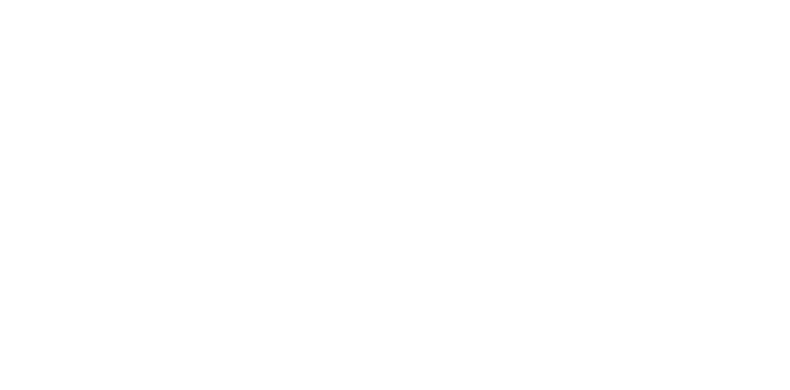

In [4]:
# Churn rate by telecom partner
churn_by_partner = df.groupby('telecom_partner_cleaned')['churn'].mean().sort_values(ascending=False)
churn_by_partner.plot(kind='bar', figsize=(8, 4), title='Churn Rate by Telecom Partner', color='steelblue')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('churn_by_partner.png', dpi=150)
plt.show()

In [5]:
# Usage metrics vs churn
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['calls_made', 'sms_sent', 'data_used']):
    df.groupby('churn')[col].mean().plot(kind='bar', ax=ax, color=['steelblue','tomato'])
    ax.set_title(f'Avg {col} by Churn')
    ax.set_xticklabels(['Retained', 'Churned'], rotation=0)
plt.tight_layout()
plt.savefig('usage_vs_churn.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

## 4. Feature Engineering & Preprocessing

- Drop columns that are not predictive (IDs, location granulars, partition key)
- Encode categorical columns with one-hot encoding
- **SageMaker XGBoost requires the target column (`churn`) to be the FIRST column in CSV**

In [6]:
# Drop non-predictive columns
DROP_COLS = ['customer_id', 'date_of_registration', 'pincode', 'city', 'partition_0']
df_model = df.drop(columns=DROP_COLS, errors='ignore').copy()

#  encode categorical columns
CAT_COLS = ['telecom_partner_cleaned', 'gender', 'state']
df_model = pd.get_dummies(df_model, columns=CAT_COLS, drop_first=True)

# Ensures all columns are numeric
df_model = df_model.astype({c: int for c in df_model.select_dtypes('bool').columns})

# Move churn to first column (XGBoost requirement)
cols = ['churn'] + [c for c in df_model.columns if c != 'churn']
df_model = df_model[cols]

print('Processed shape:', df_model.shape)
print('First 3 rows:')
df_model.head(3)

Processed shape: (243553, 38)
First 3 rows:


,churn,age,num_dependents,estimated_salary,calls_made,sms_sent,data_used,telecom_partner_cleaned_BSNL,telecom_partner_cleaned_Reliance Jio,telecom_partner_cleaned_Vodafone,...,state_Odisha,state_Punjab,state_Rajasthan,state_Sikkim,state_Tamil Nadu,state_Telangana,state_Tripura,state_Uttar Pradesh,state_Uttarakhand,state_West Bengal
0,0,25,4,124962,44,45,-361,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,55,2,130556,62,39,5973,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,57,0,148828,49,24,193,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## 5. Train / Validation / Test Split

In [7]:
# 70% train | 15% validation | 15% test
train_df, temp_df = train_test_split(df_model, test_size=0.30, random_state=42, stratify=df_model['churn'])
val_df,   test_df = train_test_split(temp_df,  test_size=0.50, random_state=42, stratify=temp_df['churn'])

print(f'Train : {train_df.shape[0]:,} rows')
print(f'Val   : {val_df.shape[0]:,} rows')
print(f'Test  : {test_df.shape[0]:,} rows')

Train : 170,487 rows
Val   : 36,533 rows
Test  : 36,533 rows


## 6. Upload Splits to S3 for SageMaker Training

In [8]:
def upload_df_to_s3(df, bucket, key):
    """Upload a DataFrame as a header-less CSV to S3."""
    buf = io.StringIO()
    df.to_csv(buf, index=False, header=False)
    boto3.client('s3').put_object(Bucket=bucket, Key=key, Body=buf.getvalue())
    return f's3://{bucket}/{key}'

train_uri = upload_df_to_s3(train_df, bucket, f'{prefix}/data/train/train.csv')
val_uri   = upload_df_to_s3(val_df,   bucket, f'{prefix}/data/validation/validation.csv')
test_df.to_csv('test_local.csv', index=False, header=False)  # keep locally for evaluation

print('Train S3 URI      :', train_uri)
print('Validation S3 URI :', val_uri)

Train S3 URI      : s3://amazon-sagemaker-372110294170-us-east-1-63yum3d7gatdt3/telecom-churn/data/train/train.csv
Validation S3 URI : s3://amazon-sagemaker-372110294170-us-east-1-63yum3d7gatdt3/telecom-churn/data/validation/validation.csv


## 7. Train XGBoost Model with SageMaker

In [9]:
# Retrieve XGBoost image
xgboost_image = sagemaker.image_uris.retrieve(
    framework='xgboost',
    region=region,
    version='1.7-1'
)

xgb = Estimator(
    image_uri          = xgboost_image,
    role               = role,
    instance_count     = 1,
    instance_type      = 'ml.m5.large',   # cost-efficient; free tier may use ml.t3.medium
    output_path        = f's3://{bucket}/{prefix}/model-output',
    sagemaker_session  = session
)

# Hyperparameters for binary classification
xgb.set_hyperparameters(
    objective          = 'binary:logistic',
    eval_metric        = 'auc',
    num_round          = 200,
    max_depth          = 5,
    eta                = 0.1,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    early_stopping_rounds = 15
)

train_input = TrainingInput(train_uri, content_type='text/csv')
val_input   = TrainingInput(val_uri,   content_type='text/csv')

xgb.fit({'train': train_input, 'validation': val_input}, logs=True)

sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment
2026-04-08 14:21:18 Starting - Starting the training job...
2026-04-08 14:21:42 Starting - Preparing the instances for training...
2026-04-08 14:22:08 Downloading - Downloading input data...
2026-04-08 14:22:53 Downloading - Downloading the training image......../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-04-08 14:24:02.947 ip-10-0-174-108.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-04-08 14:24:03.045 ip-10-0-174-108.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-04-08:14:24:03:INFO] Imported framework sagemaker_xgboost_container.tr

## 8. Deploy Model to a SageMaker Endpoint

In [10]:
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer

predictor = xgb.deploy(
    initial_instance_count = 1,
    instance_type          = 'ml.t2.medium',  
    serializer             = CSVSerializer(),
    deserializer           = CSVDeserializer()
)

print('Endpoint name:', predictor.endpoint_name)

-----------!Endpoint name: sagemaker-xgboost-2026-04-08-14-25-06-045


## 9. Evaluate Model on Test Set

In [11]:
test_data = pd.read_csv('test_local.csv', header=None)
X_test    = test_data.iloc[:, 1:]   # features (all cols except first)
y_test    = test_data.iloc[:, 0]    # true labels

# Run predictions in batches to avoid payload limits
BATCH = 500
raw_preds = []
for i in range(0, len(X_test), BATCH):
    batch   = X_test.iloc[i:i+BATCH]
    result  = predictor.predict(batch.values)
    raw_preds.extend([float(r[0]) for r in result])

y_prob = np.array(raw_preds)
y_pred = (y_prob >= 0.5).astype(int)

print('=== Model Evaluation ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

=== Model Evaluation ===
Accuracy : 0.7994
AUC-ROC  : 0.4998

              precision    recall  f1-score   support

    Retained       0.80      1.00      0.89     29209
     Churned       0.37      0.00      0.00      7324

    accuracy                           0.80     36533
   macro avg       0.58      0.50      0.45     36533
weighted avg       0.71      0.80      0.71     36533



In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
plt.title('Confusion Matrix — XGBoost Churn Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [13]:
# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_val:.3f})', color='steelblue', lw=2)
plt.plot([0,1],[0,1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## 10. Business Insights from the Model

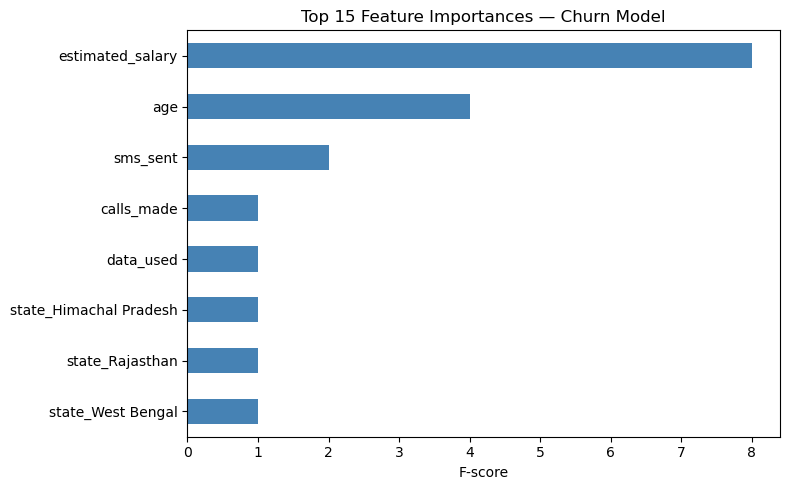

In [14]:
# Feature importance (from trained XGBoost model)
import tarfile, json, tempfile

model_uri = xgb.model_data
local_tar = '/tmp/model.tar.gz'
boto3.client('s3').download_file(
    model_uri.split('/')[2],
    '/'.join(model_uri.split('/')[3:]),
    local_tar
)

with tarfile.open(local_tar) as t:
    t.extractall('/tmp/model_extract')

import xgboost as xgb_lib
booster = xgb_lib.Booster()
booster.load_model('/tmp/model_extract/xgboost-model')

# Get feature names
feature_names = list(train_df.columns[1:])  # exclude churn column

# Map f0, f1 etc to actual names
importance = pd.Series(booster.get_fscore())
importance.index = [feature_names[int(k[1:])] for k in importance.index]
importance = importance.sort_values(ascending=False).head(15)

importance.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Top 15 Feature Importances — Churn Model')
plt.xlabel('F-score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [15]:
feature_names = list(train_df.columns[1:])  # exclude churn column
print("Feature index mapping:")
for i, name in enumerate(feature_names):
    print(f"f{i} = {name}")

Feature index mapping:
f0 = age
f1 = num_dependents
f2 = estimated_salary
f3 = calls_made
f4 = sms_sent
f5 = data_used
f6 = telecom_partner_cleaned_BSNL
f7 = telecom_partner_cleaned_Reliance Jio
f8 = telecom_partner_cleaned_Vodafone
f9 = gender_M
f10 = state_Arunachal Pradesh
f11 = state_Assam
f12 = state_Bihar
f13 = state_Chhattisgarh
f14 = state_Goa
f15 = state_Gujarat
f16 = state_Haryana
f17 = state_Himachal Pradesh
f18 = state_Jharkhand
f19 = state_Karnataka
f20 = state_Kerala
f21 = state_Madhya Pradesh
f22 = state_Maharashtra
f23 = state_Manipur
f24 = state_Meghalaya
f25 = state_Mizoram
f26 = state_Nagaland
f27 = state_Odisha
f28 = state_Punjab
f29 = state_Rajasthan
f30 = state_Sikkim
f31 = state_Tamil Nadu
f32 = state_Telangana
f33 = state_Tripura
f34 = state_Uttar Pradesh
f35 = state_Uttarakhand
f36 = state_West Bengal


## 11. Cleanup — Delete Endpoint (Important for Cost Control!)

> **Run this cell after evaluation is done to avoid ongoing endpoint charges.**

In [16]:
# Uncomment when done
# predictor.delete_endpoint()
# print('Endpoint deleted.')

## 12. MLOps — Model Registration & Versioning

Register the trained model in the **SageMaker Model Registry** for versioning and governance.

In [17]:
import boto3
from datetime import datetime

sm_client = boto3.client("sagemaker", region_name=region)

# Step 1: Create a Model Package Group (acts as a versioned container for your model)
model_package_group_name = "telecom-churn-model-group"

try:
    sm_client.create_model_package_group(
        ModelPackageGroupName=model_package_group_name,
        ModelPackageGroupDescription="Telecom churn prediction models - CS480 Capstone"
    )
    print(f"Created model group: {model_package_group_name}")
except sm_client.exceptions.ClientError as e:
    print(f"Model group already exists or error: {e}")

# Step 2: Register model version with metadata
model_url = xgb.model_data  # S3 path to trained model artifact

model_package = sm_client.create_model_package(
    ModelPackageGroupName=model_package_group_name,
    ModelPackageDescription=f"XGBoost churn classifier trained {datetime.now().strftime('%Y-%m-%d')}",
    InferenceSpecification={
        "Containers": [{
            "Image": xgboost_image,
            "ModelDataUrl": model_url,
            "Framework": "XGBOOST"
        }],
        "SupportedContentTypes": ["text/csv"],
        "SupportedResponseMIMETypes": ["text/csv"],
        "SupportedTransformInstanceTypes": ["ml.m5.large"],
        "SupportedRealtimeInferenceInstanceTypes": ["ml.t2.medium", "ml.m5.large"]
    },
    ModelApprovalStatus="PendingManualApproval",
    CustomerMetadataProperties={
        "dataset": "telecom-churn-groupproject",
        "algorithm": "XGBoost",
        "objective": "binary:logistic",
        "num_round": "200",
        "team": "CS480-Capstone"
    }
)

model_package_arn = model_package["ModelPackageArn"]
print(f"Registered model version ARN: {model_package_arn}")

Model group already exists or error: An error occurred (ValidationException) when calling the CreateModelPackageGroup operation: Model Package Group already exists: arn:aws:sagemaker:us-east-1:372110294170:model-package-group/telecom-churn-model-group
Registered model version ARN: arn:aws:sagemaker:us-east-1:372110294170:model-package/telecom-churn-model-group/5


## 13. MLOps — Approve Model & Check Endpoint Status

In [18]:
# Approve the model version (simulates a CI/CD approval gate)
sm_client.update_model_package(
    ModelPackageArn=model_package_arn,
    ModelApprovalStatus="Approved"
)
print("Model version approved.")

# List all versions in the model group
versions = sm_client.list_model_packages(
    ModelPackageGroupName=model_package_group_name,
    SortBy="CreationTime",
    SortOrder="Descending"
)
print(f"\nModel versions registered in group '{model_package_group_name}':")
for v in versions["ModelPackageSummaryList"]:
    print(f"  - Version ARN : {v['ModelPackageArn']}")
    print(f"    Status      : {v['ModelApprovalStatus']}")
    print(f"    Created     : {v['CreationTime'].strftime('%Y-%m-%d %H:%M')}")

# Check live endpoint status
endpoint_info = sm_client.describe_endpoint(EndpointName=predictor.endpoint_name)
print(f"\nEndpoint name   : {endpoint_info['EndpointName']}")
print(f"Endpoint status : {endpoint_info['EndpointStatus']}")
print(f"Created         : {endpoint_info['CreationTime'].strftime('%Y-%m-%d %H:%M')}")

Model version approved.

Model versions registered in group 'telecom-churn-model-group':
  - Version ARN : arn:aws:sagemaker:us-east-1:372110294170:model-package/telecom-churn-model-group/5
    Status      : Approved
    Created     : 2026-04-08 14:31
  - Version ARN : arn:aws:sagemaker:us-east-1:372110294170:model-package/telecom-churn-model-group/4
    Status      : Approved
    Created     : 2026-04-08 13:43
  - Version ARN : arn:aws:sagemaker:us-east-1:372110294170:model-package/telecom-churn-model-group/3
    Status      : Approved
    Created     : 2026-04-08 10:09
  - Version ARN : arn:aws:sagemaker:us-east-1:372110294170:model-package/telecom-churn-model-group/2
    Status      : Approved
    Created     : 2026-04-06 15:55
  - Version ARN : arn:aws:sagemaker:us-east-1:372110294170:model-package/telecom-churn-model-group/1
    Status      : PendingManualApproval
    Created     : 2026-04-06 15:11

Endpoint name   : sagemaker-xgboost-2026-04-08-14-25-06-045
Endpoint status : InSe

## 14. MLOps — Live Inference Test

Pass a real sample customer through the deployed endpoint to verify the full pipeline end-to-end.

In [22]:
# Grab a sample of 5 customers from the test set (features only)
sample = test_data.iloc[:5, 1:]  # drop the churn label column
actual_labels = test_data.iloc[:5, 0].tolist()

# Run live inference through the endpoint
raw = predictor.predict(sample.values)
probs = [float(r[0]) for r in raw]
preds = [1 if p >= 0.5 else 0 for p in probs]

# Display results
import pandas as pd
results_df = pd.DataFrame({
    "Actual Churn"    : actual_labels,
    "Predicted Churn" : preds,
    "Churn Probability": [f"{p:.1%}" for p in probs],
    "Correct"          : ["✓" if a == p else "✗" for a, p in zip(actual_labels, preds)]
})
print("Live inference results on 5 sample customers:")
results_df

Live inference results on 5 sample customers:


,Actual Churn,Predicted Churn,Churn Probability,Correct
0,0,0,47.0%,✓
1,0,0,47.0%,✓
2,0,0,47.0%,✓
3,0,0,47.0%,✓
4,1,0,47.0%,✗


In [23]:
# Single customer prediction 
sample_customer = test_data.iloc[0:1, 1:]  # sample customer
result = predictor.predict(sample_customer.values)
prob = float(result[0][0])

print("Live Churn Risk Assessment")
print(f"Customer features:")
print(sample_customer.to_string())
print(f"\nChurn probability : {prob:.1%}")
if prob >= 0.5:
    print("Risk level        : HIGH RISK — recommend retention offer")
else:
    print("Risk level        : LOW RISK — no immediate action needed")

Live Churn Risk Assessment
Customer features:
   1   2      3   4   5     6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
0  20   2  47961  18   6  3755   0   0   0   1   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

Churn probability : 47.0%
Risk level        : LOW RISK — no immediate action needed
